### Single Agent

In [ ]:
import numpy as np

# Parameters
valuation = 50
discount_rate = 0.999
learning_rate = 0.01
epsilon_start = 0.99
epsilon_min = 0.01
epsilon_decay = 0.9999999
num_rounds = 10
num_actions = 5
num_games = 10_000_000
verbose_interval = 10000

actions = np.arange(num_actions)  # Action space 0-10
q_table = np.random.uniform(valuation,valuation+1,(num_rounds + 1, 2, len(actions)))  # Q-table
p = np.arange(num_actions,0,-1)**3.0
p /= p.sum()
print(p)

def train_agent():
    global epsilon_start
    reward_history_q = []
    reward_history_random = []
    epsilon = epsilon_start

    for game in range(num_games):
        t = num_rounds
        s = 0
        current_bid_q = 0
        current_bid_random = 0

        while t > 0:
            state_q = (t, s)
            action_q = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table[state_q])]
            current_bid_q += action_q
            action_random = np.random.choice(actions, p=p)
            current_bid_random += action_random
            s = 1 if current_bid_q >= current_bid_random else 0
            t -= 1
        reward_q = (valuation - current_bid_q) if (current_bid_q > current_bid_random) and (current_bid_q <= valuation) else 0
        reward_random = (valuation - current_bid_random) if (current_bid_random > current_bid_q) and (current_bid_random <= valuation) else 0
        reward_history_q.append(reward_q)
        reward_history_random.append(reward_random)

        if (game + 1) % verbose_interval == 0:
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Q-Learn: {np.mean(reward_history_q[-verbose_interval:])}, Avg Random: {np.mean(reward_history_random[-verbose_interval:])}")

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        state_q = (num_rounds, s)  # Reset state for Q-learning update
        update_q(state_q, action_q, reward_q, (t, s), t == 1)

    return q_table, reward_history_q, reward_history_random

def update_q(state, action, reward, next_state, done):
    future = 0 if done else discount_rate * np.max(q_table[next_state])
    q_table[state][action] += learning_rate * (reward + future - q_table[state][action])

q_table, reward_history_q, reward_history_random = train_agent()


[0.55555556 0.28444444 0.12       0.03555556 0.00444444]
Game 10000: Epsilon: 0.9890, Avg Q-Learn: 29.8244, Avg Random: 0.1487
Game 20000: Epsilon: 0.9880, Avg Q-Learn: 29.7276, Avg Random: 0.142
Game 30000: Epsilon: 0.9870, Avg Q-Learn: 29.7887, Avg Random: 0.1544
Game 40000: Epsilon: 0.9860, Avg Q-Learn: 29.8084, Avg Random: 0.1138
Game 50000: Epsilon: 0.9851, Avg Q-Learn: 29.78, Avg Random: 0.167
Game 60000: Epsilon: 0.9841, Avg Q-Learn: 29.7888, Avg Random: 0.1482
Game 70000: Epsilon: 0.9831, Avg Q-Learn: 29.808, Avg Random: 0.1706
Game 80000: Epsilon: 0.9821, Avg Q-Learn: 29.7733, Avg Random: 0.1785
Game 90000: Epsilon: 0.9811, Avg Q-Learn: 29.756, Avg Random: 0.1484
Game 100000: Epsilon: 0.9801, Avg Q-Learn: 29.8353, Avg Random: 0.1279
Game 110000: Epsilon: 0.9792, Avg Q-Learn: 29.7649, Avg Random: 0.1786
Game 120000: Epsilon: 0.9782, Avg Q-Learn: 29.8407, Avg Random: 0.1507
Game 130000: Epsilon: 0.9772, Avg Q-Learn: 29.8659, Avg Random: 0.146
Game 140000: Epsilon: 0.9762, Avg Q-

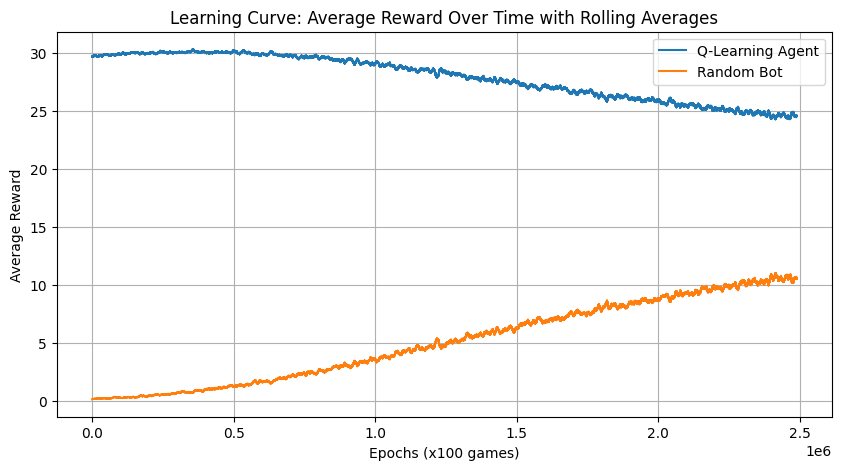

In [2]:
import matplotlib.pyplot as plt
import numpy as np
window_size = 10000
rolling_avg_q = np.convolve(reward_history_q, np.ones(window_size)/window_size, mode='valid')
rolling_avg_random = np.convolve(reward_history_random, np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(10, 5))
plt.plot(rolling_avg_q, label='Q-Learning Agent')
plt.plot(rolling_avg_random, label='Random Bot')
plt.xlabel('Epochs (x100 games)')
plt.ylabel('Average Reward')
plt.title('Learning Curve: Average Reward Over Time with Rolling Averages')
plt.legend()
plt.grid(True)
plt.show()

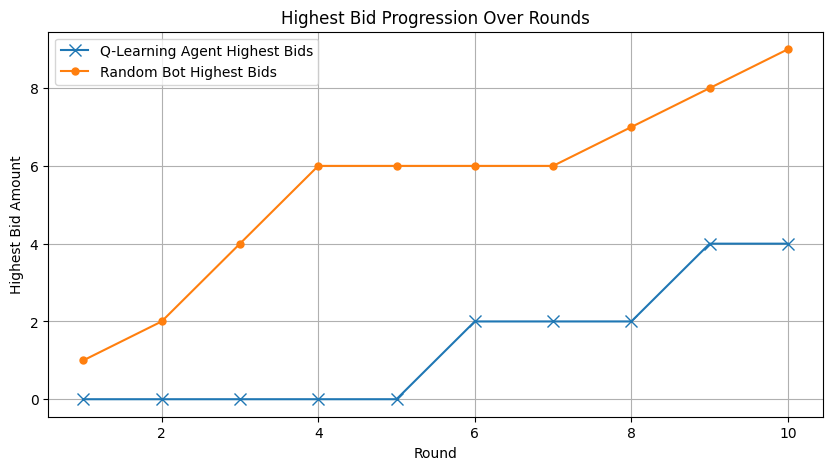

Reward for Q-Learning Agent: 0
Reward for Random Bot: 41


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_game(q_table):
    t = num_rounds
    s = 0
    current_bid_q = 0
    current_bid_random = 0
    highest_bids_q = []
    highest_bids_random = []

    while t > 0:
        state_q = (t, s)
        action_q = actions[np.argmax(q_table[state_q])]  # Choose best action from Q-table
        current_bid_q += action_q
        highest_bids_q.append(current_bid_q)

        action_random = np.random.choice(actions, p=p)
        current_bid_random += action_random
        highest_bids_random.append(current_bid_random)

        s = 1 if current_bid_q >= current_bid_random else 0
        t -= 1

    reward_q = (valuation - current_bid_q) if (current_bid_q > current_bid_random) and (current_bid_q <= valuation) else 0
    reward_random = (valuation - current_bid_random) if (current_bid_random > current_bid_q) and (current_bid_random <= valuation) else 0

    # Plotting the highest bids in correct round order with markers
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q, 'x-', label='Q-Learning Agent Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_random, 'o-', label='Random Bot Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Highest Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Reward for Q-Learning Agent: {reward_q}")
    print(f"Reward for Random Bot: {reward_random}")

# Example of calling the function with a pre-trained q_table
simulate_game(q_table)

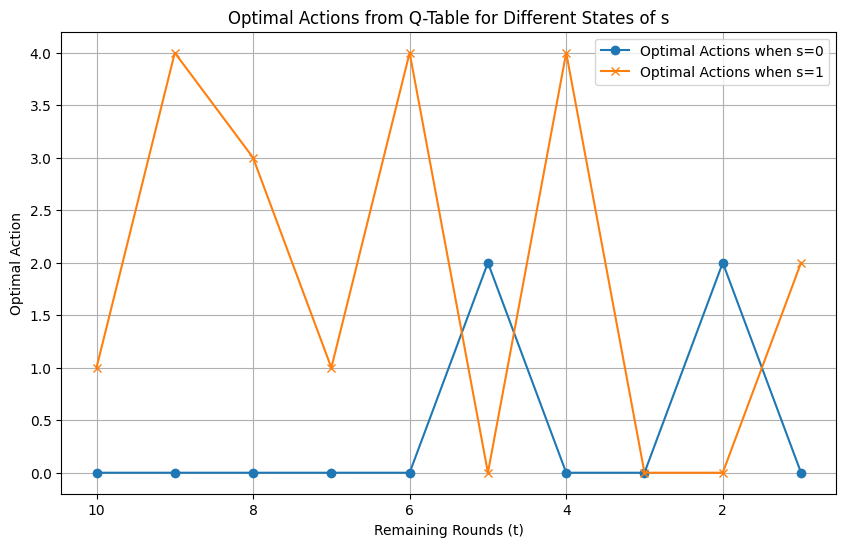

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming q_table is the Q-table from the trained Q-learning model
num_rounds = 10  # Total number of rounds, from 10 to 1

# Extract optimal actions for each state of 's' across all rounds
optimal_actions_s0 = [np.argmax(q_table[t, 0]) for t in range(1, num_rounds+1)]
optimal_actions_s1 = [np.argmax(q_table[t, 1]) for t in range(1, num_rounds+1)]

# Plot the optimal actions
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_rounds+1), optimal_actions_s0, 'o-', label='Optimal Actions when s=0')
plt.plot(range(1, num_rounds+1), optimal_actions_s1, 'x-', label='Optimal Actions when s=1')
plt.gca().invert_xaxis()  # Invert x-axis to show decreasing rounds from left to right
plt.xlabel('Remaining Rounds (t)')
plt.ylabel('Optimal Action')
plt.title('Optimal Actions from Q-Table for Different States of s')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def interactive_game(q_table):
    t = num_rounds
    s = 0  # Initial state: no one has the highest bid
    current_bid_q = 0
    current_bid_your = 0
    past_bids_q = []

    print("Starting the game. You will bid against the Q-learning bot.")

    while t > 0:
        state_q = (t, s)
        action_q = actions[np.argmax(q_table[state_q])]  # Bot selects the best action based on the Q-table
        current_bid_q += action_q
        past_bids_q.append(action_q)  # Store this round's bid for future reference

        # You enter your bid
        print(f"Round {num_rounds - t + 1}")
        print(f"Past bids by bot: {past_bids_q[:-1]}")  # Show all past bids except the current one
        print(f"Currently holding the highest bid: {'You' if s == 0 else 'Bot'}")

        try:
            bid = int(input("Enter your bid (0-4): "))
            if bid < 0 or bid > 10:
                print("Invalid bid. Please enter a value between 0 and 10.")
                continue
        except ValueError:
            print("Invalid input. Please enter an integer value.")
            continue

        current_bid_your += bid
        s = 1 if current_bid_q >= current_bid_your else 0  # Update the state based on who has the highest bid
        t -= 1  # Decrease the round

        print(f"Your total bid so far: {current_bid_your}\n")

    reward_q = (valuation - current_bid_q) if (current_bid_q > current_bid_your) and (current_bid_q <= valuation) else 0

    # Output results
    print("Game over.")
    print("Q-learning bot's total bid:", current_bid_q)
    print("Your total bid:", current_bid_your)
    print("Reward for Q-Learning Agent:", reward_q)

# Call this function to start an interactive game
interactive_game(q_table)


### Eligibility Traces

In [6]:
import numpy as np

# Parameters
valuation = 50
discount_rate = 0.999
learning_rate = 0.01
lambda_ = 0.9  # Eligibility trace decay parameter
epsilon_start = 0.99
epsilon_min = 0.01
epsilon_decay = 0.99995
num_rounds = 10
num_actions = 5
num_games = 100000
verbose_interval = 10000

actions = np.arange(num_actions)  # Action space
q_table = np.random.uniform(valuation, valuation + 1, (num_rounds + 1, 2, len(actions)))  # Q-table
p = np.arange(num_actions, 0, -1)**3.0
p /= p.sum()

def train_agent():
    global epsilon_start, q_table  # Add q_table to global declarations

    reward_history_q = []
    reward_history_random = []
    epsilon = epsilon_start

    for game in range(num_games):
        # Initialize eligibility traces
        e_trace = np.zeros_like(q_table)

        t = num_rounds
        s = 0
        current_bid_q = 0
        current_bid_random = 0

        while t > 0:
            state_q = (t, s)
            if np.random.rand() < epsilon:
                action_q = np.random.choice(actions)
            else:
                action_q = actions[np.argmax(q_table[state_q])]

            current_bid_q += action_q
            action_random = np.random.choice(actions, p=p)
            current_bid_random += action_random
            s = 1 if current_bid_q >= current_bid_random else 0

            # Update eligibility trace
            e_trace *= discount_rate * lambda_
            e_trace[state_q][action_q] += 1

            if t == 1:  # Reward only on the final round
                reward_q = (valuation - current_bid_q) if (current_bid_q > current_bid_random) and (current_bid_q <= valuation) else 0
                reward_random = (valuation - current_bid_random) if (current_bid_random > current_bid_q) and (current_bid_random <= valuation) else 0

                # Q-value and eligibility trace update
                delta = reward_q - q_table[state_q][action_q]
                q_table += learning_rate * delta * e_trace

            t -= 1

        reward_history_q.append(reward_q)
        reward_history_random.append(reward_random)

        if (game + 1) % verbose_interval == 0:
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Q-Learn: {np.mean(reward_history_q[-verbose_interval:])}, Avg Random: {np.mean(reward_history_random[-verbose_interval:])}")

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q_table, reward_history_q, reward_history_random

# Then train the agent
q_table, reward_history_q, reward_history_random = train_agent()


Game 10000: Epsilon: 0.6005, Avg Q-Learn: 32.6747, Avg Random: 0.3712
Game 20000: Epsilon: 0.3642, Avg Q-Learn: 35.6787, Avg Random: 0.5622
Game 30000: Epsilon: 0.2209, Avg Q-Learn: 36.9188, Avg Random: 0.6844
Game 40000: Epsilon: 0.1340, Avg Q-Learn: 37.5807, Avg Random: 0.692
Game 50000: Epsilon: 0.0813, Avg Q-Learn: 38.1507, Avg Random: 0.4835
Game 60000: Epsilon: 0.0493, Avg Q-Learn: 38.1601, Avg Random: 0.4797
Game 70000: Epsilon: 0.0299, Avg Q-Learn: 38.0396, Avg Random: 0.4523
Game 80000: Epsilon: 0.0181, Avg Q-Learn: 38.6419, Avg Random: 0.384
Game 90000: Epsilon: 0.0110, Avg Q-Learn: 38.5851, Avg Random: 0.468
Game 100000: Epsilon: 0.0100, Avg Q-Learn: 38.6885, Avg Random: 0.4118


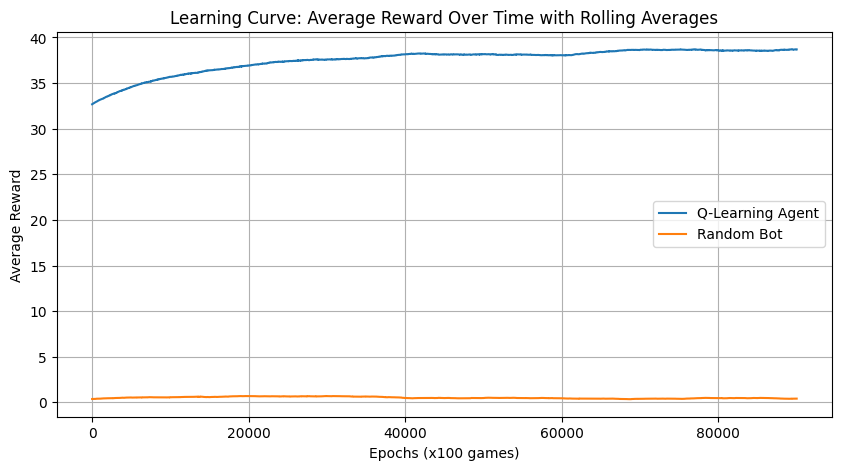

In [7]:
import matplotlib.pyplot as plt
import numpy as np
window_size = 10000
rolling_avg_q = np.convolve(reward_history_q, np.ones(window_size)/window_size, mode='valid')
rolling_avg_random = np.convolve(reward_history_random, np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(10, 5))
plt.plot(rolling_avg_q, label='Q-Learning Agent')
plt.plot(rolling_avg_random, label='Random Bot')
plt.xlabel('Epochs (x100 games)')
plt.ylabel('Average Reward')
plt.title('Learning Curve: Average Reward Over Time with Rolling Averages')
plt.legend()
plt.grid(True)
plt.show()

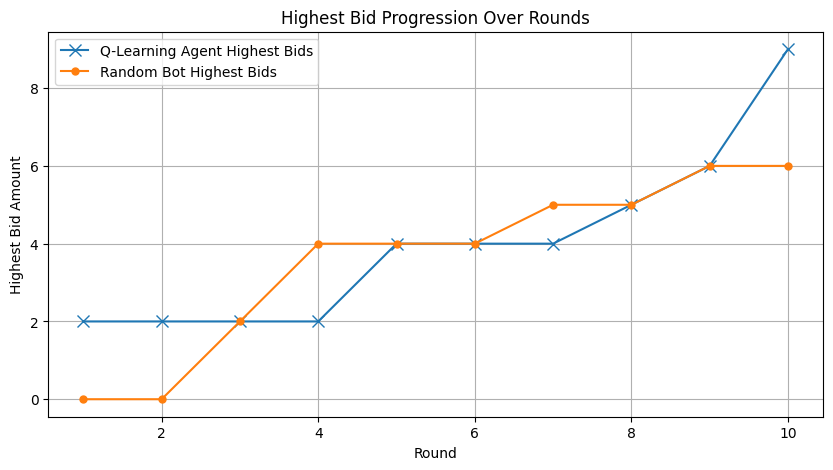

Reward for Q-Learning Agent: 41
Reward for Random Bot: 0


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_game(q_table):
    t = num_rounds
    s = 0
    current_bid_q = 0
    current_bid_random = 0
    highest_bids_q = []
    highest_bids_random = []

    while t > 0:
        state_q = (t, s)
        action_q = actions[np.argmax(q_table[state_q])]  # Choose best action from Q-table
        current_bid_q += action_q
        highest_bids_q.append(current_bid_q)

        action_random = np.random.choice(actions, p=p)
        current_bid_random += action_random
        highest_bids_random.append(current_bid_random)

        s = 1 if current_bid_q >= current_bid_random else 0
        t -= 1

    reward_q = (valuation - current_bid_q) if (current_bid_q > current_bid_random) and (current_bid_q <= valuation) else 0
    reward_random = (valuation - current_bid_random) if (current_bid_random > current_bid_q) and (current_bid_random <= valuation) else 0

    # Plotting the highest bids in correct round order with markers
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q, 'x-', label='Q-Learning Agent Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_random, 'o-', label='Random Bot Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Highest Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Reward for Q-Learning Agent: {reward_q}")
    print(f"Reward for Random Bot: {reward_random}")

# Example of calling the function with a pre-trained q_table
simulate_game(q_table)


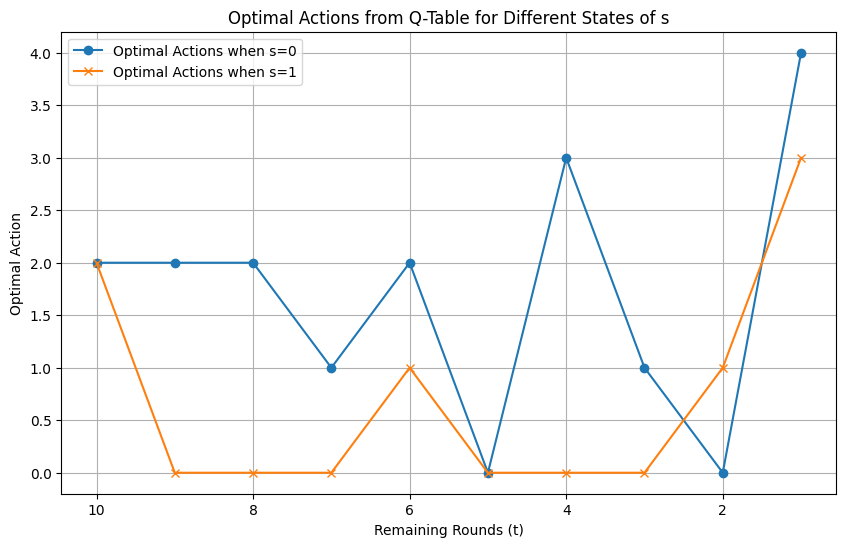

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming q_table is the Q-table from the trained Q-learning model
num_rounds = 10  # Total number of rounds, from 10 to 1

# Extract optimal actions for each state of 's' across all rounds
optimal_actions_s0 = [np.argmax(q_table[t, 0]) for t in range(1, num_rounds+1)]
optimal_actions_s1 = [np.argmax(q_table[t, 1]) for t in range(1, num_rounds+1)]

# Plot the optimal actions
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_rounds+1), optimal_actions_s0, 'o-', label='Optimal Actions when s=0')
plt.plot(range(1, num_rounds+1), optimal_actions_s1, 'x-', label='Optimal Actions when s=1')
plt.gca().invert_xaxis()  # Invert x-axis to show decreasing rounds from left to right
plt.xlabel('Remaining Rounds (t)')
plt.ylabel('Optimal Action')
plt.title('Optimal Actions from Q-Table for Different States of s')
plt.legend()
plt.grid(True)
plt.show()


### vs Random-Creeper-OneShotter

In [12]:
# Fixing the probabilities issue by ensuring they sum to 1 for the creeper bot's random action

import numpy as np

# Parameters
val = 100
disc = 0.999
lr = 0.01
lam = 0.9
eps_start = 0.99
eps_min = 0.01
eps_decay = 0.999999  # Reduced epsilon decay
rounds = 10
actions = 10
games = 3000000
verbose = 100000

acts = np.arange(actions)
q_tab = np.random.uniform(val, val + 1, (rounds + 1, 2, 2, actions))

def random_bot_type():
    return np.random.choice(["creeper", "sniper"])

def random_bot_action(bot_type, t, holds_bid):
    if bot_type == "creeper":
        if holds_bid:
            probs = [0.6] + [0.1] * (actions - 1)
            return np.random.choice(acts, p=probs/np.sum(probs))
        else:
            probs = [0.1] * (actions - 1) + [0.2]
            return np.random.choice(acts, p=probs/np.sum(probs))
    elif bot_type == "sniper" and t == 1:
        return actions - 1
    else:
        return 0

def train_agent():
    global eps_start, q_tab

    r_hist_q = []
    r_hist_rnd = []
    eps = eps_start

    for game in range(games):
        e_trace = np.zeros_like(q_tab)
        bot_type = random_bot_type()
        held_count = 0

        t = rounds
        s = 0
        current_bid_q = 0
        current_bid_rnd = 0

        while t > 0:
            state_q = (t, s, min(1, held_count))  # Ensure held_count is within bounds
            if np.random.rand() < eps:
                act_q = np.random.choice(acts)
            else:
                act_q = acts[np.argmax(q_tab[state_q])]

            current_bid_q += act_q
            act_rnd = random_bot_action(bot_type, t, current_bid_rnd >= current_bid_q)
            current_bid_rnd += act_rnd
            s = 1 if current_bid_q >= current_bid_rnd else 0
            if s == 1:
                held_count += 1

            e_trace *= disc * lam
            e_trace[state_q][act_q] += 1

            if t == 1:
                reward_q = (val - current_bid_q) if (current_bid_q > current_bid_rnd) and (current_bid_q <= val) else 0
                reward_rnd = (val - current_bid_rnd) if (current_bid_rnd > current_bid_q) and (current_bid_rnd <= val) else 0
                delta = reward_q - q_tab[state_q][act_q]
                q_tab += lr * delta * e_trace

            t -= 1

        r_hist_q.append(reward_q)
        r_hist_rnd.append(reward_rnd)

        if (game + 1) % verbose == 0:
            print(f"Game {game + 1}: Eps: {eps:.4f}, Avg Q: {np.mean(r_hist_q[-verbose:]):.4f}, Avg Rnd: {np.mean(r_hist_rnd[-verbose:]):.4f}")

        eps = max(eps_min, eps * eps_decay)

    return q_tab, r_hist_q, r_hist_rnd

q_tab, r_hist_q, r_hist_rnd = train_agent()


Game 100000: Eps: 0.8958, Avg Q: 40.2698, Avg Rnd: 13.2304
Game 200000: Eps: 0.8105, Avg Q: 40.8237, Avg Rnd: 15.4437
Game 300000: Eps: 0.7334, Avg Q: 41.7089, Avg Rnd: 16.6590
Game 400000: Eps: 0.6636, Avg Q: 42.7359, Avg Rnd: 17.4506
Game 500000: Eps: 0.6005, Avg Q: 43.7209, Avg Rnd: 17.7124
Game 600000: Eps: 0.5433, Avg Q: 44.7708, Avg Rnd: 17.9024
Game 700000: Eps: 0.4916, Avg Q: 45.3163, Avg Rnd: 18.0169
Game 800000: Eps: 0.4448, Avg Q: 45.9251, Avg Rnd: 18.1286
Game 900000: Eps: 0.4025, Avg Q: 46.3383, Avg Rnd: 18.3254
Game 1000000: Eps: 0.3642, Avg Q: 46.8824, Avg Rnd: 18.2875
Game 1100000: Eps: 0.3295, Avg Q: 46.6689, Avg Rnd: 18.6920
Game 1200000: Eps: 0.2982, Avg Q: 46.7651, Avg Rnd: 18.6748
Game 1300000: Eps: 0.2698, Avg Q: 46.7038, Avg Rnd: 18.5257
Game 1400000: Eps: 0.2441, Avg Q: 46.4301, Avg Rnd: 18.2522
Game 1500000: Eps: 0.2209, Avg Q: 45.7225, Avg Rnd: 18.5311
Game 1600000: Eps: 0.1999, Avg Q: 45.6407, Avg Rnd: 17.6989
Game 1700000: Eps: 0.1809, Avg Q: 49.0611, Avg Rn

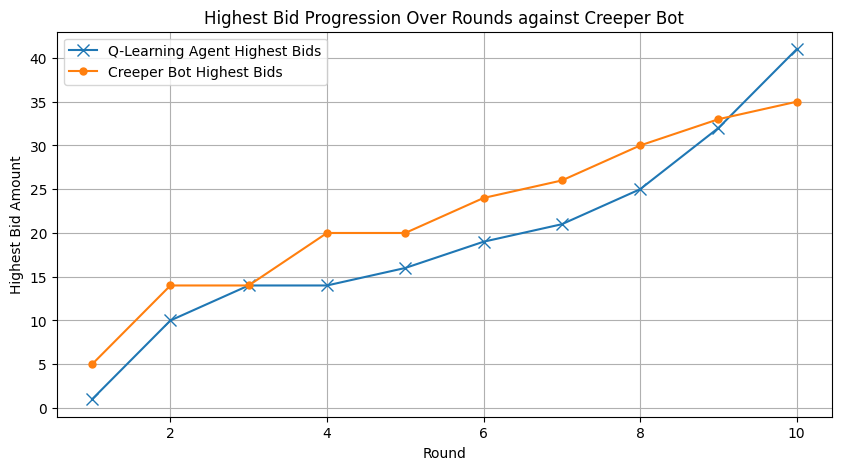

Reward for Q-Learning Agent: 59
Reward for Creeper Bot: 0


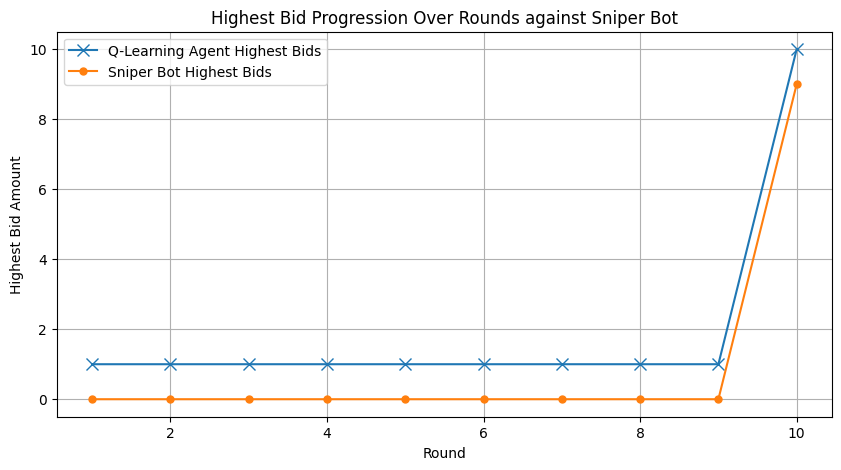

Reward for Q-Learning Agent: 90
Reward for Sniper Bot: 0


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_game(q_table, bot_type="creeper"):
    t = rounds
    s = 0
    held_count = 0
    current_bid_q = 0
    current_bid_rnd = 0
    highest_bids_q = []
    highest_bids_rnd = []

    while t > 0:
        state_q = (t, s, min(1, held_count))  # Ensure held_count is within bounds
        action_q = acts[np.argmax(q_table[state_q])]  # Choose best action from Q-table
        current_bid_q += action_q
        highest_bids_q.append(current_bid_q)

        action_rnd = random_bot_action(bot_type, t, current_bid_rnd >= current_bid_q)
        current_bid_rnd += action_rnd
        highest_bids_rnd.append(current_bid_rnd)

        s = 1 if current_bid_q >= current_bid_rnd else 0
        if s == 1:
            held_count += 1
        t -= 1

    reward_q = (val - current_bid_q) if (current_bid_q > current_bid_rnd) and (current_bid_q <= val) else 0
    reward_rnd = (val - current_bid_rnd) if (current_bid_rnd > current_bid_q) and (current_bid_rnd <= val) else 0

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, rounds+1), highest_bids_q, 'x-', label='Q-Learning Agent Highest Bids', markersize=8)
    plt.plot(range(1, rounds+1), highest_bids_rnd, 'o-', label=f'{bot_type.capitalize()} Bot Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Highest Bid Amount')
    plt.title(f'Highest Bid Progression Over Rounds against {bot_type.capitalize()} Bot')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Reward for Q-Learning Agent: {reward_q}")
    print(f"Reward for {bot_type.capitalize()} Bot: {reward_rnd}")

# Example of calling the function with a pre-trained q_table against a creeper bot
simulate_game(q_tab, bot_type="creeper")

# Example of calling the function with a pre-trained q_table against a sniper bot
simulate_game(q_tab, bot_type="sniper")

### Vs 3 Types

Game 100000: Eps: 0.8958, Avg Q: 45.9906, Avg Rnd: 8.7293
Game 200000: Eps: 0.8105, Avg Q: 47.5699, Avg Rnd: 10.2712
Game 300000: Eps: 0.7334, Avg Q: 49.1630, Avg Rnd: 11.3438
Game 400000: Eps: 0.6636, Avg Q: 50.6928, Avg Rnd: 12.2674
Game 500000: Eps: 0.6005, Avg Q: 51.4662, Avg Rnd: 13.3948
Game 600000: Eps: 0.5433, Avg Q: 52.1895, Avg Rnd: 14.3106
Game 700000: Eps: 0.4916, Avg Q: 53.2428, Avg Rnd: 14.7820
Game 800000: Eps: 0.4448, Avg Q: 53.4987, Avg Rnd: 15.6134
Game 900000: Eps: 0.4025, Avg Q: 54.2678, Avg Rnd: 15.6548
Game 1000000: Eps: 0.3642, Avg Q: 54.5733, Avg Rnd: 15.8590
Game 1100000: Eps: 0.3295, Avg Q: 55.0697, Avg Rnd: 16.0960
Game 1200000: Eps: 0.2982, Avg Q: 55.4800, Avg Rnd: 16.2407
Game 1300000: Eps: 0.2698, Avg Q: 55.7751, Avg Rnd: 16.4967
Game 1400000: Eps: 0.2441, Avg Q: 56.3219, Avg Rnd: 16.7418
Game 1500000: Eps: 0.2209, Avg Q: 56.5679, Avg Rnd: 16.9955
Game 1600000: Eps: 0.1999, Avg Q: 56.9655, Avg Rnd: 16.9956
Game 1700000: Eps: 0.1809, Avg Q: 57.1330, Avg Rnd

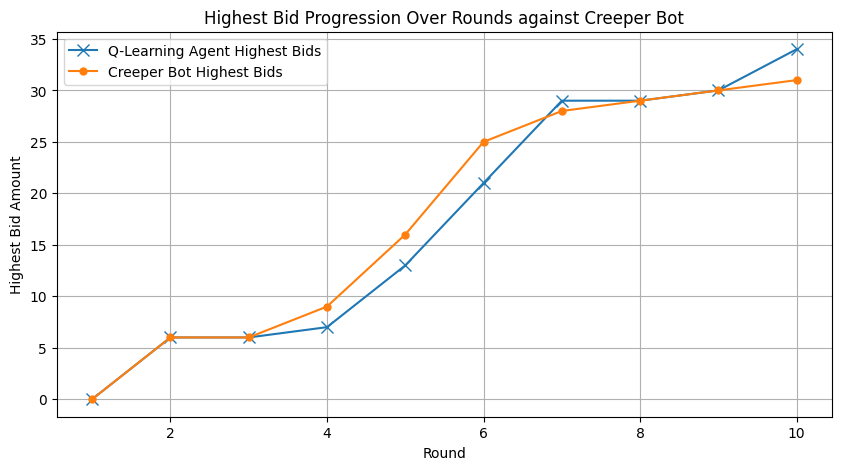

Reward for Q-Learning Agent: 66
Reward for Creeper Bot: 0


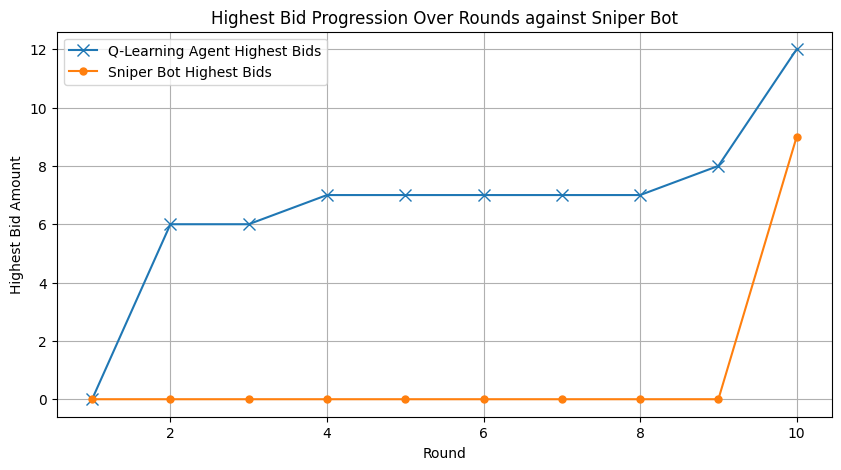

Reward for Q-Learning Agent: 88
Reward for Sniper Bot: 0


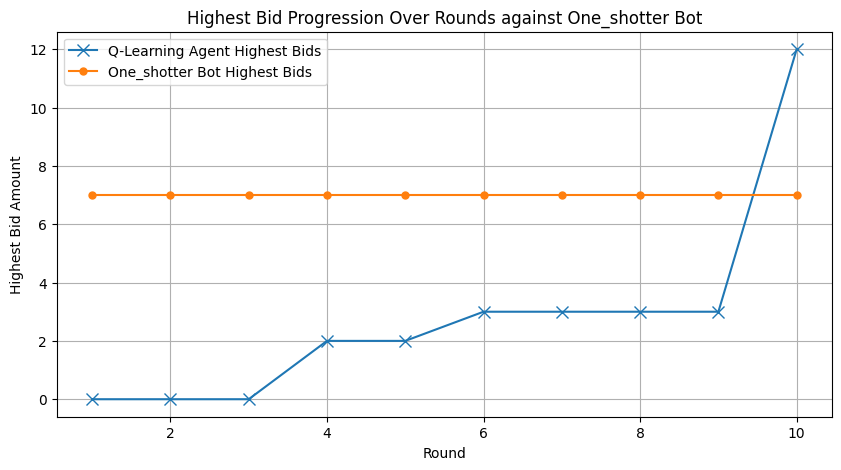

Reward for Q-Learning Agent: 88
Reward for One_shotter Bot: 0


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
val = 100
disc = 0.999
lr = 0.01
lam = 0.9
eps_start = 0.99
eps_min = 0.01
eps_decay = 0.999999  # Reduced epsilon decay
rounds = 10
actions = 10
games = 3000000
verbose = 100000

acts = np.arange(actions)
q_tab = np.random.uniform(val, val + 1, (rounds + 1, 2, 2, actions))

def random_bot_type():
    return np.random.choice(["creeper", "sniper", "one_shotter"], p=[0.33, 0.33, 0.34])

def random_bot_action(bot_type, t, holds_bid):
    if bot_type == "creeper":
        if holds_bid:
            probs = [0.6] + [0.1] * (actions - 1)
            return np.random.choice(acts, p=probs/np.sum(probs))
        else:
            probs = [0.1] * (actions - 1) + [0.2]
            return np.random.choice(acts, p=probs/np.sum(probs))
    elif bot_type == "sniper" and t == 1:
        return actions - 1
    elif bot_type == "one_shotter" and t == rounds:
        return actions - 3  # One-shotter bids fairly high early on
    else:
        return 0

def train_agent():
    global eps_start, q_tab

    r_hist_q = []
    r_hist_rnd = []
    eps = eps_start

    for game in range(games):
        e_trace = np.zeros_like(q_tab)
        bot_type = random_bot_type()
        held_count = 0

        t = rounds
        s = 0
        current_bid_q = 0
        current_bid_rnd = 0

        while t > 0:
            state_q = (t, s, min(1, held_count))  # Ensure held_count is within bounds
            if np.random.rand() < eps:
                act_q = np.random.choice(acts)
            else:
                act_q = acts[np.argmax(q_tab[state_q])]

            current_bid_q += act_q
            act_rnd = random_bot_action(bot_type, t, current_bid_rnd >= current_bid_q)
            current_bid_rnd += act_rnd
            s = 1 if current_bid_q >= current_bid_rnd else 0
            if s == 1:
                held_count += 1

            e_trace *= disc * lam
            e_trace[state_q][act_q] += 1

            if t == 1:
                reward_q = (val - current_bid_q) if (current_bid_q > current_bid_rnd) and (current_bid_q <= val) else 0
                reward_rnd = (val - current_bid_rnd) if (current_bid_rnd > current_bid_q) and (current_bid_rnd <= val) else 0
                delta = reward_q - q_tab[state_q][act_q]
                q_tab += lr * delta * e_trace

            t -= 1

        r_hist_q.append(reward_q)
        r_hist_rnd.append(reward_rnd)

        if (game + 1) % verbose == 0:
            print(f"Game {game + 1}: Eps: {eps:.4f}, Avg Q: {np.mean(r_hist_q[-verbose:]):.4f}, Avg Rnd: {np.mean(r_hist_rnd[-verbose:]):.4f}")

        eps = max(eps_min, eps * eps_decay)

    return q_tab, r_hist_q, r_hist_rnd

q_tab, r_hist_q, r_hist_rnd = train_agent()

def simulate_game(q_table, bot_type="creeper"):
    t = rounds
    s = 0
    held_count = 0
    current_bid_q = 0
    current_bid_rnd = 0
    highest_bids_q = []
    highest_bids_rnd = []

    while t > 0:
        state_q = (t, s, min(1, held_count))  # Ensure held_count is within bounds
        action_q = acts[np.argmax(q_table[state_q])]  # Choose best action from Q-table
        current_bid_q += action_q
        highest_bids_q.append(current_bid_q)

        action_rnd = random_bot_action(bot_type, t, current_bid_rnd >= current_bid_q)
        current_bid_rnd += action_rnd
        highest_bids_rnd.append(current_bid_rnd)

        s = 1 if current_bid_q >= current_bid_rnd else 0
        if s == 1:
            held_count += 1
        t -= 1

    reward_q = (val - current_bid_q) if (current_bid_q > current_bid_rnd) and (current_bid_q <= val) else 0
    reward_rnd = (val - current_bid_rnd) if (current_bid_rnd > current_bid_q) and (current_bid_rnd <= val) else 0

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, rounds+1), highest_bids_q, 'x-', label='Q-Learning Agent Highest Bids', markersize=8)
    plt.plot(range(1, rounds+1), highest_bids_rnd, 'o-', label=f'{bot_type.capitalize()} Bot Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Highest Bid Amount')
    plt.title(f'Highest Bid Progression Over Rounds against {bot_type.capitalize()} Bot')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Reward for Q-Learning Agent: {reward_q}")
    print(f"Reward for {bot_type.capitalize()} Bot: {reward_rnd}")

# Example of calling the function with a pre-trained q_table against a creeper bot
simulate_game(q_tab, bot_type="creeper")
simulate_game(q_tab, bot_type="sniper")
simulate_game(q_tab, bot_type="one_shotter")

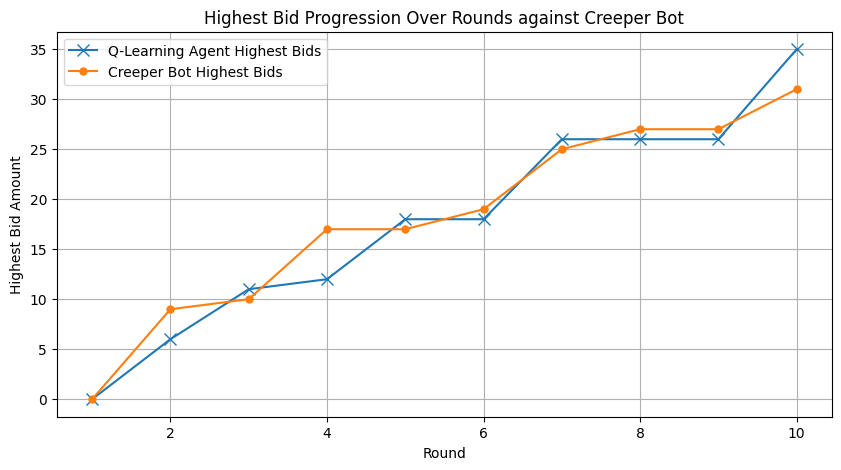

Reward for Q-Learning Agent: 65
Reward for Creeper Bot: 0


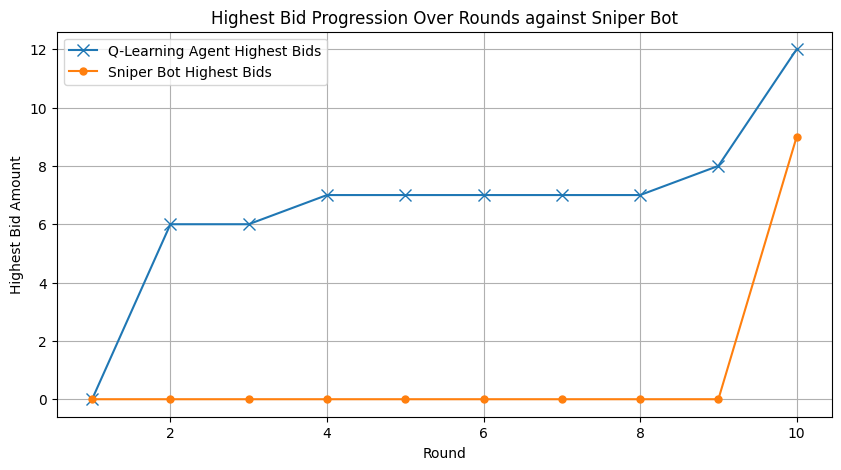

Reward for Q-Learning Agent: 88
Reward for Sniper Bot: 0


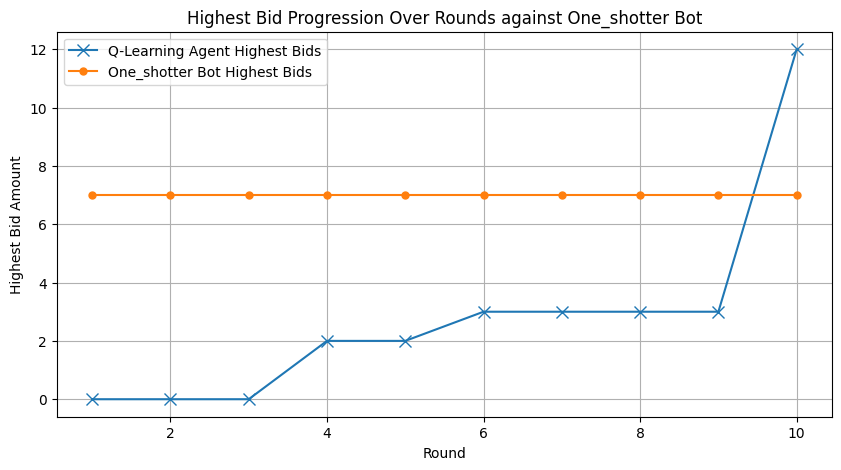

Reward for Q-Learning Agent: 88
Reward for One_shotter Bot: 0


In [20]:
simulate_game(q_tab, bot_type="creeper")
simulate_game(q_tab, bot_type="sniper")
simulate_game(q_tab, bot_type="one_shotter")